
## Fourier Neural Operator Robustness and Resolution Invariance

#### Tao Wang, Ph.D. Student

##### [LinkedIn](https://www.linkedin.com/in/tao-wang-b6b872325/) | [GoogleScholar](https://scholar.google.com/citations?user=LM0otm8AAAAJ&hl=en)
#### Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering

### Subsurface Machine Learning Course, The University of Texas at Austin

_____________________

Workflow supervised and reviewed by:

#### Instructor: Prof. Michael Pyrcz, Ph.D., P.Eng., Associate Professor, The Univeristy of Texas at Austin
[Twitter](https://twitter.com/geostatsguy) | [GitHub](https://github.com/GeostatsGuy) | [Website](http://michaelpyrcz.com) | [GoogleScholar](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en&oi=ao) | [Geostatistics Book](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) | [YouTube](https://www.youtube.com/channel/UCLqEr-xV-ceHdXXXrTId5ig)  | [Applied Geostats in Python e-book](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) | [Applied Machine Learning in Python e-book](https://geostatsguy.github.io/MachineLearningDemos_Book/) | [LinkedIn](https://www.linkedin.com/in/michael-pyrcz-61a648a1)

#### Course TA: Maria Gonzalez, Ph.D. Student, The University of Texas at Austin


### A Brief Summary of Fourier Neural Operators

Fourier Neural Operators (FNOs) are neural architectures designed to learn resolution-invariant solution operator mappings from input function spaces to output function spaces as in partial differential equations (PDEs).

* Operator Learning: Instead of giving predctions at discrete points, FNOs learn solution operators—mappings between the entire input and output functions. This characteristics enpowers them to have high generality across different resolutions and domains.
* Fourier Transform: The Fast Fourier Transform (FFT) is leveraged to represent functions in the frequency domain, enabling efficient capture of nonlocal dependencies that challenges traditional convolutional networks.

### Executive Summary

This project aims to demonstrate the robustness of Fourier Neural Operator (FNO) against the noise in inputs and its resolution invaraint property. The Fourier Neural Operator has been used in multiple applications. The demonstration in this project is focused on a 2D Darcy flow as descriped in the original paper ([paper_link](https://doi.org/10.48550/arXiv.2010.08895)) and the corresponding data can be downloaded form ([data_link](https://drive.google.com/drive/folders/1UnbQh2WWc6knEHbLn-ZaXrKUZhp7pjt-?usp=sharing)). The soruce code of FNO models can be found at ([source_code](https://github.com/neuraloperator/neuraloperator/tree/main/neuralop)). For more information on the numerical experiment of the 2D Darcy flow, please refer to the original paper. 

For robustness of Fourier Neural Operator (FNO), I train the FNO2d model on a grid of 85 by 85 and load the trained FNO2d model to give predictions with inputs with increasing noise level from 0, 0.15, 0.30, to 0.45 and calculate the corresponding relative error using L2 norm of the predictions against references to quantify how the model predictions degrade with increasing noise level in the inputs.

The FNO2d model is trained on a Darcy flow problem of resolution of 85 by 85. To test its resolution invariant ability, I sample the input and output spaces with a resolution of 61 by 61 which is only half of the resolution for training the model. To match the input size of the trained FNO2d model on a 85 by 85 grid, the inputs on low resolution is upsampled to 85 by 85 and predictions on 85 by 85 are then downsampled to 61 by 61 to make comparison with references on a grid of 61 by 61.

### Import Packages and Setup the Dirctory

Before you start, make sure you have PyTorch and CUDA configured on your device. 

Here are some useful links for configuring your device: [PyTorch](https://pytorch.org/) | [CUDA](https://developer.nvidia.com/cuda-toolkit).


In [1]:
import os, random
os.chdir('e:/UT Austin/Study/Term 7 2025 Fall/Subsurface Machine Learning/term_project')          # set the working directory correctly
dataset_path = './datasets' ## folder directory for storing the datasets
model_path = './pre_train' ## folder directory for storing the trained models
pred_path = './model_pred' ## folder directory for storing the model predictions
paths = [dataset_path, model_path, pred_path]
for path in paths:
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Created the folder: {path}")
    else:
        print(f"The folder already exists: {path}")
    
import torch.nn.functional as F
import matplotlib.pyplot as plt
from timeit import default_timer
from utilities3 import *

torch.manual_seed(0)  ## random seed for reproductivity
np.random.seed(0)  ## random seed for reproductivity
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # Choose a device either CPU or GPU to run the model

The folder already exists: ./datasets
The folder already exists: ./pre_train
The folder already exists: ./model_pred


This part will help to build some necessary folders in the specified directory.

### FNO2d Class

The following FNO2d class is a standard one, for more information, please refer to the original paper([paper_link](https://doi.org/10.48550/arXiv.2010.08895)) and GitHub repo ([soruce_code](https://github.com/neuraloperator/neuraloperator/tree/main/neuralop)).

In [2]:
class SpectralConv2d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1, modes2):
        super(SpectralConv2d, self).__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1
        self.modes2 = modes2

        self.scale = (1 / (in_channels * out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))
        self.weights2 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, self.modes2, dtype=torch.cfloat))

    def compl_mul2d(self, input, weights):
        return torch.einsum("bixy,ioxy->boxy", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        x_ft = torch.fft.rfft2(x)

        out_ft = torch.zeros(batchsize, self.out_channels,  x.size(-2), x.size(-1)//2 + 1, dtype=torch.cfloat, device=x.device)
        out_ft[:, :, :self.modes1, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, :self.modes1, :self.modes2], self.weights1)
        out_ft[:, :, -self.modes1:, :self.modes2] = \
            self.compl_mul2d(x_ft[:, :, -self.modes1:, :self.modes2], self.weights2)

        x = torch.fft.irfft2(out_ft, s=(x.size(-2), x.size(-1)))
        return x

class MLP(nn.Module):
    def __init__(self, in_channels, out_channels, mid_channels):
        super(MLP, self).__init__()
        self.mlp1 = nn.Conv2d(in_channels, mid_channels, 1)
        self.mlp2 = nn.Conv2d(mid_channels, out_channels, 1)

    def forward(self, x):
        x = self.mlp1(x)
        x = F.gelu(x)
        x = self.mlp2(x)
        return x

class FNO2d(nn.Module):
    def __init__(self, modes1, modes2,  width):
        super(FNO2d, self).__init__()
        
        self.modes1 = modes1
        self.modes2 = modes2
        self.width = width
        self.padding = 9

        self.p = nn.Linear(3, self.width)
        self.conv0 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv1 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv2 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.conv3 = SpectralConv2d(self.width, self.width, self.modes1, self.modes2)
        self.mlp0 = MLP(self.width, self.width, self.width)
        self.mlp1 = MLP(self.width, self.width, self.width)
        self.mlp2 = MLP(self.width, self.width, self.width)
        self.mlp3 = MLP(self.width, self.width, self.width)
        self.w0 = nn.Conv2d(self.width, self.width, 1)
        self.w1 = nn.Conv2d(self.width, self.width, 1)
        self.w2 = nn.Conv2d(self.width, self.width, 1)
        self.w3 = nn.Conv2d(self.width, self.width, 1)
        self.q = MLP(self.width, 1, self.width * 4)

    def forward(self, x):
        grid = self.get_grid(x.shape, x.device)
        x = torch.cat((x, grid), dim=-1)
        x = self.p(x)
        x = x.permute(0, 3, 1, 2)
        x = F.pad(x, [0,self.padding, 0,self.padding])

        x1 = self.conv0(x)
        x1 = self.mlp0(x1)
        x2 = self.w0(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv1(x)
        x1 = self.mlp1(x1)
        x2 = self.w1(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv2(x)
        x1 = self.mlp2(x1)
        x2 = self.w2(x)
        x = x1 + x2
        x = F.gelu(x)

        x1 = self.conv3(x)
        x1 = self.mlp3(x1)
        x2 = self.w3(x)
        x = x1 + x2

        x = x[..., :-self.padding, :-self.padding]
        x = self.q(x)
        x = x.permute(0, 2, 3, 1)
        return x
    
    def get_grid(self, shape, device):
        batchsize, size_x, size_y = shape[0], shape[1], shape[2]
        gridx = torch.tensor(np.linspace(0, 1, size_x), dtype=torch.float)
        gridx = gridx.reshape(1, size_x, 1, 1).repeat([batchsize, 1, size_y, 1])
        gridy = torch.tensor(np.linspace(0, 1, size_y), dtype=torch.float)
        gridy = gridy.reshape(1, 1, size_y, 1).repeat([batchsize, size_x, 1, 1])
        return torch.cat((gridx, gridy), dim=-1).to(device)

### Data Loading and Training Configuration

We will work on a 2D Darcy flow dataset in which inputs are 2D permeability fields and outputs are 2D pressure fields.
* Load the datasets.
* Configure the hyperparameters for the FNO2d model.

In [3]:
TRAIN_PATH = './Darcy_421/piececonst_r421_N1024_smooth1.mat'
TEST_PATH = './Darcy_421/piececonst_r421_N1024_smooth2.mat'

ntrain = 1000
ntest = 200

batch_size = 20
learning_rate = 0.001
epochs = 100
iterations = epochs*(ntrain//batch_size)

modes = 12
width = 32

### Data Spliting, Generation, Normalization, and Saving
* Training and testing datasets are individually loaded from TRAIN_PATH and TEST_PATH.
* Apply different strides on the second and third dimension to get datasets at different resolutions.
* Apply min-max normalization to the training and testing datasets.
* Save the datasets to loacl directories for later use.

In [4]:
r_list = [5, 7] ## r=5 for high resolution datasets, r=7 for low resolution datasets
for i in range(2):
    r = r_list[i]
    h = int(((421 - 1)/r) + 1)
    s = h
    if i == 0: ## high resolution dataset 85*85
        reader = MatReader(TRAIN_PATH)
        x_train = reader.read_field('coeff')[:ntrain,::r,::r][:,:s,:s]
        y_train = reader.read_field('sol')[:ntrain,::r,::r][:,:s,:s]

        reader.load_file(TEST_PATH)
        x_test = reader.read_field('coeff')[:ntest,::r,::r][:,:s,:s]
        y_test = reader.read_field('sol')[:ntest,::r,::r][:,:s,:s]

        x_normalizer = UnitGaussianNormalizer(x_train)
        x_train = x_normalizer.encode(x_train)
        x_test = x_normalizer.encode(x_test)

        torch.save(x_train, f"./datasets/x_train_{h}.pt")
        torch.save(x_test, f"./datasets/x_test_{h}.pt")

        y_normalizer = UnitGaussianNormalizer(y_train)
        y_train = y_normalizer.encode(y_train)
        y_test = y_normalizer.encode(y_test)

        torch.save(y_train, f"./datasets/y_train_{h}.pt")
        torch.save(y_test, f"./datasets/y_test_{h}.pt")
    else: ## low resolution dataset 61*61
        reader = MatReader(TRAIN_PATH)
        x_train = reader.read_field('coeff')[:ntrain,::r,::r][:,:s,:s]
        y_train = reader.read_field('sol')[:ntrain,::r,::r][:,:s,:s]

        reader.load_file(TEST_PATH)
        x_test = reader.read_field('coeff')[:ntest,::r,::r][:,:s,:s]
        y_test = reader.read_field('sol')[:ntest,::r,::r][:,:s,:s]

        x_normalizer = UnitGaussianNormalizer(x_train)
        x_train = x_normalizer.encode(x_train)
        x_test = x_normalizer.encode(x_test)

        torch.save(x_test, f"./datasets/x_test_{h}.pt")

        y_normalizer = UnitGaussianNormalizer(y_train)
        y_train = y_normalizer.encode(y_train)
        y_test = y_normalizer.encode(y_test)

        torch.save(y_test, f"./datasets/y_test_{h}.pt")

### Load Datasets for Training the FNO2d Model

1. Load x_train and x_test and reshape them to the right shapes.

2. Load y_train and y_test.

In [5]:
r = r_list[0]
h = int(((421 - 1)/r) + 1)
s = h
x_train = torch.load(f"./datasets/x_train_{h}.pt", weights_only=True).reshape(ntrain, s, s, 1)
x_test = torch.load(f"./datasets/x_test_{h}.pt", weights_only=True).reshape(ntest, s, s, 1)

y_train = torch.load(f"./datasets/y_train_{h}.pt", weights_only=True)
y_test = torch.load(f"./datasets/y_test_{h}.pt", weights_only=True)

### Training the FNO2d Model
You should expect the output like the follows:

Total trainable parameters: 2376449.

1   4.9432   0.7102   0.4639  
2   3.1308   0.4568   0.4311  
3   3.1109   0.4151   0.3642  
......  

98  3.0841   0.0469   0.0569  
99  3.1103   0.0469   0.0569  
100 3.2320   0.0469   0.0569  

Training finishes in 321.6 seconds.

In [6]:
train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_train, y_train), batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_test, y_test), batch_size=batch_size, shuffle=False)

# training and evaluation
device = torch.device('cuda') # Choose GPU to train the model
train_start = default_timer()
model = FNO2d(modes, modes, width).to(device)
print(f"Total trainable parameters: {count_params(model)}.\n")

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iterations)

myloss = LpLoss(size_average=False)

y_normalizer.cuda()
for ep in range(epochs):
    model.train()
    t1 = default_timer()
    train_l2 = 0
    for x, y in train_loader:
        x, y = x.cuda(), y.cuda()

        optimizer.zero_grad()
        out = model(x).reshape(batch_size, s, s)

        loss = myloss(out.view(batch_size, -1), y.view(batch_size, -1))
        loss.backward()

        optimizer.step()
        scheduler.step()
        train_l2 += loss.item()

    model.eval()
    test_l2 = 0.0
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.cuda(), y.cuda()

            out = model(x).reshape(batch_size, s, s)

            test_l2 += myloss(out.view(batch_size, -1), y.view(batch_size, -1)).item()

    train_l2/= ntrain
    test_l2 /= ntest

    t2 = default_timer()
    print(ep+1, round(t2-t1, 4), round(train_l2, 4), round(test_l2, 4))
    
torch.save(model.state_dict(), './pre_train/fno2d_darcy_85.dt') ## save the 2D FNO model trained on 85*85 high resolution dataset
train_end = default_timer()
print(f"\nTraining finishes in {round(train_end-train_start, 2)} seconds.\n")

Total trainable parameters: 2376449.

1 5.6204 0.7102 0.4639
2 3.4783 0.4568 0.4311
3 3.3104 0.4151 0.3642
4 3.3181 0.3333 0.2798
5 3.4446 0.2493 0.232
6 3.6324 0.2062 0.2127
7 3.3138 0.1837 0.1652
8 3.2998 0.1557 0.153
9 3.3118 0.1398 0.1382
10 3.5282 0.1319 0.1349
11 3.5903 0.1216 0.1202
12 3.3133 0.113 0.1178
13 3.3091 0.1129 0.1091
14 3.4125 0.1072 0.1101
15 3.5414 0.1038 0.1062
16 3.4676 0.0946 0.0983
17 3.3171 0.089 0.0936
18 3.3133 0.0904 0.1009
19 3.4278 0.0852 0.0882
20 3.6588 0.0822 0.0881
21 3.377 0.0859 0.0894
22 3.3106 0.0874 0.0927
23 3.3242 0.0817 0.0881
24 3.5583 0.0765 0.0829
25 3.5798 0.0748 0.0798
26 3.3879 0.0735 0.0787
27 3.3627 0.0732 0.0851
28 3.5209 0.0719 0.0855
29 3.5754 0.072 0.0827
30 3.4475 0.0686 0.0775
31 3.3259 0.0677 0.0773
32 3.3369 0.0702 0.0759
33 3.5499 0.0709 0.0779
34 3.6134 0.0674 0.0717
35 3.3618 0.0637 0.0751
36 3.3052 0.0656 0.0727
37 3.4865 0.0649 0.0709
38 3.7507 0.0622 0.0721
39 3.6557 0.0616 0.0688
40 3.539 0.0627 0.0691
41 3.4715 0.0609 0

### Load the Trained FNO2d Model to Give Predictions

* Load x_test and y_test.
* Reshape x_test to the right shape.
* Sequentially add random noises to x_test, save the noised datasets, load the pre-trained FNO2d model to give predictions for noised inputs, and save results.
* Calculate the L2 relative error between y_pred against y_test to quantify the degradation of the FNO2d model predictions.

In [7]:
# load the saved model and do the prediction with noise at resolution of 85*85
model = FNO2d(modes, modes, width).to('cpu') ## use CPU for prediction

x_test = torch.load(f"./datasets/x_test_{h}.pt" ,weights_only=True)
y_test = torch.load(f"./datasets/y_test_{h}.pt" ,weights_only=True)

x_test = x_test.reshape(ntest, s, s, 1)

## add random gaussian noise to x_test
std_list = [0, 0.15, 0.30, 0.45]
mean = 0
for i in range(4):
    std = std_list[i]
    x_test = x_test + torch.randn_like(x_test) * std + mean
    torch.save(x_test, f"./datasets/x_test_{h}_{std}.pt")
    test_start = default_timer()
    model.load_state_dict(torch.load('./pre_train/fno2d_darcy_85.dt', map_location='cpu' ,weights_only=True))
    model.eval()

    test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_test, y_test), batch_size=ntest, shuffle=False)
    with torch.no_grad():
        for x, y in test_loader:
             test_l2 = 0
             x, y = x.cpu(), y.cpu()
             out = model(x)
             test_l2 += myloss(out, y).item()
             print(f"\nTesting L2: {round(test_l2/ntest, 4)}.")
        pred = out
        torch.save(pred, f"./model_pred/pred_darcy_{h}_{std}.pt")
    test_end = default_timer()
    print(f"Testing finishes in {round(test_end-test_start, 2)} seconds.\n")


Testing L2: 0.0569.
Testing finishes in 10.24 seconds.


Testing L2: 0.0597.
Testing finishes in 10.17 seconds.


Testing L2: 0.0737.
Testing finishes in 10.32 seconds.


Testing L2: 0.1063.
Testing finishes in 10.33 seconds.



### Visualize Robustness of FNO2d Model

* We start with defining the plot fucntion: pcolor_fields().
* Then we define the meshgrid for ploting these 2D fields.
* We will have a big plot with 4*4 subplots, arranged in the order: the first row for results with no noise, the second row for results with N(0. 0.15), the third row for results with N(0, 0.30), etc. In each row, the subplots are arranged in the order of input, reference, prediction, and difference.

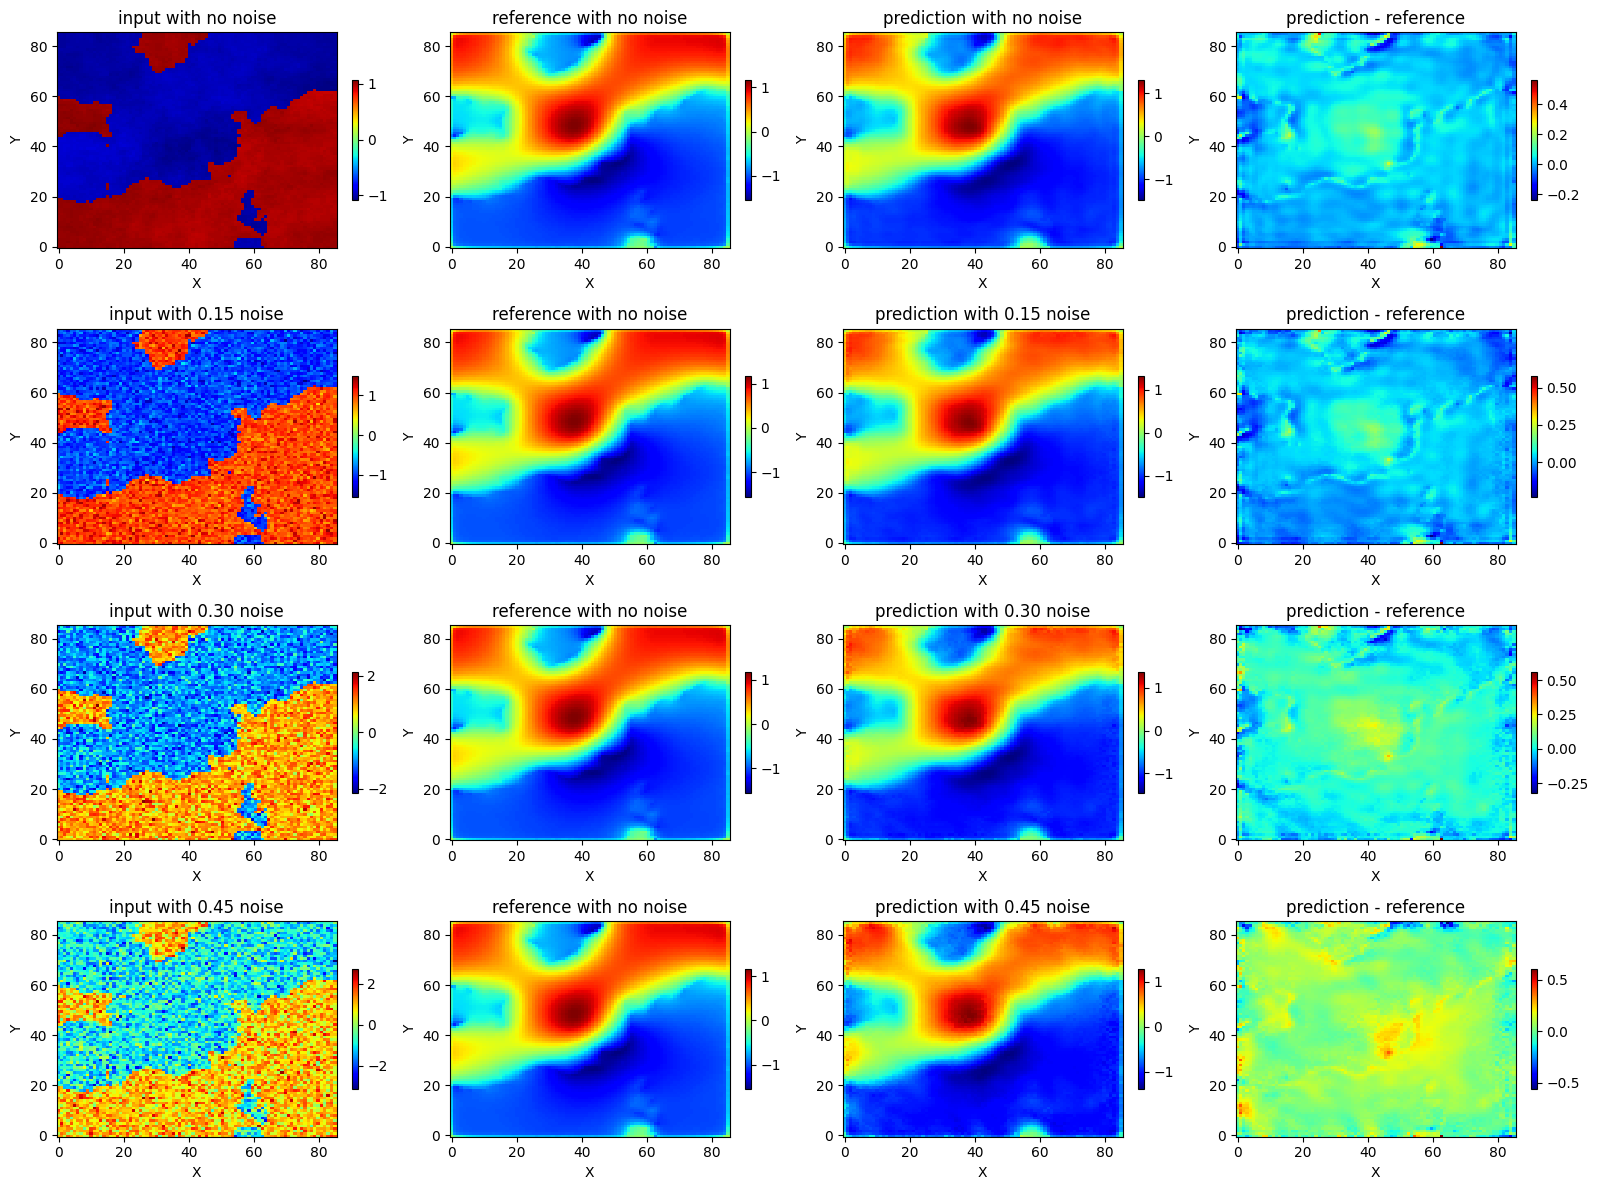

In [8]:
## visualize the robustness of FNO2d model against noise in input at resolution 85*85

def pcolor_fields(x):
    plt.set_cmap('jet')
    return plt.pcolor(X, Y, np.flipud(x), shading='nearest')

index = random.randint(0, 199) ## randomly select one case in testing dataset to visualize

# Prepare for plotting
X, Y = np.meshgrid(np.linspace(0, 85, num = 85), np.linspace(0, 85, num = 85))

plt.figure(figsize=(16, 12))    
for i in range(4):        
    if i == 0: ## plot the case without noise
       ## input plot
       plt.subplot(4,4,i*4+1)
       pcolor_fields(torch.load('./datasets/x_test_85_0.pt', weights_only=True).squeeze().numpy()[index, :])
       plt.title('input with no noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)
        
       ## reference plot
       plt.subplot(4,4,i*4+2)
       pcolor_fields(torch.load('./datasets/y_test_85.pt', weights_only=True).numpy()[index, :])
       plt.title('reference with no noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)

       ## prediction plot
       plt.subplot(4,4,i*4+3)
       pcolor_fields(torch.load('./model_pred/pred_darcy_85_0.pt', weights_only=True).numpy()[index, :].squeeze())
       plt.title('prediction with no noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)

       ## difference plot 
       plt.subplot(4,4,i*4+4)
       pcolor_fields((torch.load('./model_pred/pred_darcy_85_0.pt', weights_only=True).squeeze().numpy()[index, :]-torch.load('./datasets/y_test_85.pt', weights_only=True).squeeze().numpy()[index, :]))
       plt.colorbar(fraction=0.02)
       plt.title('prediction - reference')
       plt.xlabel("X")
       plt.ylabel("Y")
                     
    elif i == 1: ## plot the case with 0.15 noise
       ## input plot
       plt.subplot(4,4,i*4+1)
       pcolor_fields(torch.load('./datasets/x_test_85_0.15.pt', weights_only=True).squeeze().numpy()[index, :])
       plt.title('input with 0.15 noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)
        
       ## reference plot
       plt.subplot(4,4,i*4+2)
       pcolor_fields(torch.load('./datasets/y_test_85.pt', weights_only=True).numpy()[index, :])
       plt.title('reference with no noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)

       ## prediction plot
       plt.subplot(4,4,i*4+3)
       pcolor_fields(torch.load('./model_pred/pred_darcy_85_0.15.pt', weights_only=True).numpy()[index, :].squeeze())
       plt.title('prediction with 0.15 noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)

       ## difference plot 
       plt.subplot(4,4,i*4+4)
       pcolor_fields((torch.load('./model_pred/pred_darcy_85_0.15.pt', weights_only=True).squeeze().numpy()[index, :]-torch.load('./datasets/y_test_85.pt', weights_only=True).squeeze().numpy()[index, :]))
       plt.colorbar(fraction=0.02)
       plt.title('prediction - reference')
       plt.xlabel("X")
       plt.ylabel("Y")
        
    elif i == 2: ## plot the case with 0.30 noise
       ## input plot
       plt.subplot(4,4,i*4+1)
       pcolor_fields(torch.load('./datasets/x_test_85_0.3.pt', weights_only=True).squeeze().numpy()[index, :])
       plt.title('input with 0.30 noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)
        
       ## reference plot
       plt.subplot(4,4,i*4+2)
       pcolor_fields(torch.load('./datasets/y_test_85.pt', weights_only=True).numpy()[index, :])
       plt.title('reference with no noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)

       ## prediction plot
       plt.subplot(4,4,i*4+3)
       pcolor_fields(torch.load('./model_pred/pred_darcy_85_0.3.pt', weights_only=True).numpy()[index, :].squeeze())
       plt.title('prediction with 0.30 noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)

       ## difference plot 
       plt.subplot(4,4,i*4+4)
       pcolor_fields((torch.load('./model_pred/pred_darcy_85_0.3.pt', weights_only=True).squeeze().numpy()[index, :]-torch.load('./datasets/y_test_85.pt', weights_only=True).squeeze().numpy()[index, :]))
       plt.colorbar(fraction=0.02)
       plt.title('prediction - reference')
       plt.xlabel("X")
       plt.ylabel("Y")

    else: ## plot the case with 0.45 noise
       ## input plot
       plt.subplot(4,4,i*4+1)
       pcolor_fields(torch.load('./datasets/x_test_85_0.45.pt', weights_only=True).squeeze().numpy()[index, :])
       plt.title('input with 0.45 noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)
        
       ## reference plot
       plt.subplot(4,4,i*4+2)
       pcolor_fields(torch.load('./datasets/y_test_85.pt', weights_only=True).numpy()[index, :])
       plt.title('reference with no noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)

       ## prediction plot
       plt.subplot(4,4,i*4+3)
       pcolor_fields(torch.load('./model_pred/pred_darcy_85_0.45.pt', weights_only=True).numpy()[index, :].squeeze())
       plt.title('prediction with 0.45 noise')
       plt.xlabel("X")
       plt.ylabel("Y")
       plt.colorbar(fraction=0.02)

       ## difference plot 
       plt.subplot(4,4,i*4+4)
       pcolor_fields((torch.load('./model_pred/pred_darcy_85_0.45.pt', weights_only=True).squeeze().numpy()[index, :]-torch.load('./datasets/y_test_85.pt', weights_only=True).squeeze().numpy()[index, :]))
       plt.colorbar(fraction=0.02)
       plt.title('prediction - reference')
       plt.xlabel("X")
       plt.ylabel("Y")
        
plt.tight_layout()
# plt.savefig(f"./FNO2d_robustness_darcy_{index}.png", dpi=300, bbox_inches='tight')
plt.show() 

### Load FNO2d Model to Perform Resolution Invariance

* Load x_test and y_test at resolution of 61 by 61.
* Upsample x_test to resolution of 85 by 85.
* Load the FNO2d model trained on resolution of 85 by 85 to give predictions of the upsampled x_test_85 and downsample the predictions to the resolution of 61 by 61.
* Calculate the L2 relative error between y_pred against y_test to quantify if there is degradation of the FNO2d model predictions.

Expected output looks like:

Testing L2: 0.0655.
Testing finishes in 8.21 seconds.

In [9]:
# load the saved model trained on resolution 85*85 and do the prediction at a different resolution of 61*61 

r = r_list[1]
h = int(((421 - 1)/r) + 1)
s = h
test_start = default_timer()
model = FNO2d(modes, modes, width).to('cpu') ## use CPU for prediction

x_test = torch.load(f"./datasets/x_test_{h}.pt" ,weights_only=True)
y_test = torch.load(f"./datasets/y_test_{h}.pt" ,weights_only=True)

# Upsample to (85, 85)
x_test = x_test.unsqueeze(1)
x_test_85 = F.interpolate(x_test, size=(85, 85), mode='bilinear', align_corners=False)

x_test_85 = x_test_85.reshape(ntest, 85, 85, 1)

torch.save(x_test_85, f"./datasets/x_test_85.pt")

model.load_state_dict(torch.load('./pre_train/fno2d_darcy_85.dt', map_location='cpu' ,weights_only=True))
model.eval()

test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(x_test_85, y_test), batch_size=ntest, shuffle=False)
with torch.no_grad():
    for x, y in test_loader:
        test_l2 = 0
        x, y = x.cpu(), y.cpu()

        out = model(x)
        out = out.permute(0, 3, 1, 2)
        out = F.interpolate(out, size=(61, 61), mode='bilinear', align_corners=False)
        out = out.squeeze(1)

        test_l2 += myloss(out, y).item()
        
        print(f"\nTesting L2: {round(test_l2/ntest, 4)}.")
        
    pred = out
    torch.save(pred, f"./model_pred/pred_darcy_61-85-61_upsampled.pt")
test_end = default_timer()
print(f"Testing finishes in {round(test_end-test_start, 2)} seconds.\n")


Testing L2: 0.0655.
Testing finishes in 10.24 seconds.



### Visualize Resolution Invariant of FNO2d Model

* We start with defining the plot fucntion: pcolor_fields().
* Then we define the meshgrid for ploting these 2D fields.
* We will have one row plot with 1*4 subplots. In the row, the subplots are arranged in the order of input, reference, prediction, and difference.

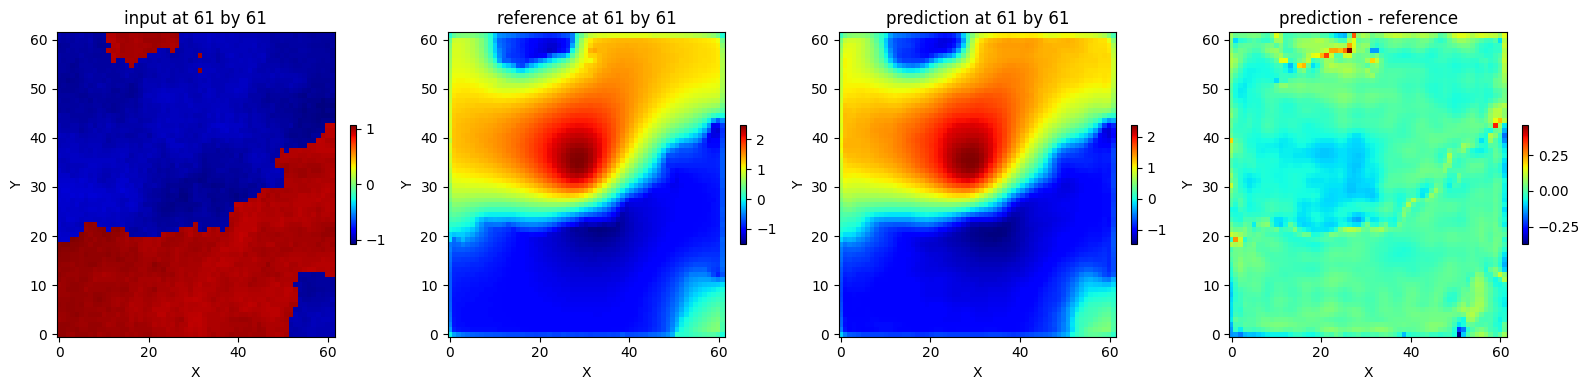

In [12]:
## visualize the resolution invariant of FNO2d model

index = random.randint(0, 199) ## randomly select one case in testing dataset to visualize

# Prepare for plotting
X, Y = np.meshgrid(np.linspace(0, 61, num = 61), np.linspace(0, 61, num = 61))

plt.figure(figsize=(16, 4)) 

## input plot
plt.subplot(1,4,1)
pcolor_fields(torch.load('./datasets/x_test_61.pt', weights_only=True).squeeze().numpy()[index, :])
plt.title('input at 61 by 61')
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(fraction=0.02)
        
## reference plot
plt.subplot(1,4,2)
pcolor_fields(torch.load('./datasets/y_test_61.pt', weights_only=True).numpy()[index, :])
plt.title('reference at 61 by 61')
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(fraction=0.02)

## prediction plot
plt.subplot(1,4,3)
pcolor_fields(torch.load('./model_pred/pred_darcy_61-85-61_upsampled.pt', weights_only=True).numpy()[index, :].squeeze())
plt.title('prediction at 61 by 61')
plt.xlabel("X")
plt.ylabel("Y")
plt.colorbar(fraction=0.02)

## difference plot 
plt.subplot(1,4,4)
pcolor_fields((torch.load('./model_pred/pred_darcy_61-85-61_upsampled.pt', weights_only=True).squeeze().numpy()[index, :]-torch.load('./datasets/y_test_61.pt', weights_only=True).squeeze().numpy()[index, :]))
plt.colorbar(fraction=0.02)
plt.title('prediction - reference')
plt.xlabel("X")
plt.ylabel("Y")

plt.tight_layout()
# plt.savefig(f"./FNO2d_resolution_invariant_darcy_{index}.png", dpi=300, bbox_inches='tight')
plt.show() 

### Results
This project aims to demonstrate the robustness of Fourier Neural Operator (FNO) against the noise in inputs and its resolution invaraint property on a publicly available 2D Darcy flow dataset.

* Robustness of Fourier Neural Operator

The average relative testing L2 loss of 200 testing samples remains consistently within the noise level of N(0, 0.30), which demonstrates the robustness of FNO2d model against noise. And the trained model starts to degrade performance when the noise level is approaching N(0, 0.45). The trained FNO2d model exhibits very strong robustness against increasing level of noise.The visulization of the prediction degradation over increasing noise level is also provided.

* Resolution invariant of Fourier Neural Operator

The corresponding average relative testing L2 loss of 200 testing samples on low resolution grid is 0.0655 (very close to 0.0569) when testing on the trained model on high resolution. Despite some degradation on the prediction accuracy, the results confirm the validation of resolution invariance of FNO2d model.

#### About the Supervising Professor

Michael Pyrcz is a professor in the [Cockrell School of Engineering](https://cockrell.utexas.edu/faculty-directory/alphabetical/p), and the [Jackson School of Geosciences](https://www.jsg.utexas.edu/researcher/michael_pyrcz/), at [The University of Texas at Austin](https://www.utexas.edu/), where he researches and teaches subsurface, spatial data analytics, geostatistics, and machine learning. Michael is also,

* the principal investigator of the [Energy Analytics](https://fri.cns.utexas.edu/energy-analytics) freshmen research initiative and a core faculty in the Machine Learn Laboratory in the College of Natural Sciences, The University of Texas at Austin

* an associate editor for [Computers and Geosciences](https://www.sciencedirect.com/journal/computers-and-geosciences/about/editorial-board), and a board member for [Mathematical Geosciences](https://link.springer.com/journal/11004/editorial-board), the International Association for Mathematical Geosciences. 

Michael has written over 70 [peer-reviewed publications](https://scholar.google.com/citations?user=QVZ20eQAAAAJ&hl=en), a [Python package](https://pypi.org/project/geostatspy/) for spatial data analytics, co-authored a textbook on spatial data analytics, [Geostatistical Reservoir Modeling](https://www.amazon.com/Geostatistical-Reservoir-Modeling-Michael-Pyrcz/dp/0199731446) and author of two recently released e-books, [Applied Geostatistics in Python: a Hands-on Guide with GeostatsPy](https://geostatsguy.github.io/GeostatsPyDemos_Book/intro.html) and [Applied Machine Learning in Python: a Hands-on Guide with Code](https://geostatsguy.github.io/MachineLearningDemos_Book/intro.html).

All of Michael’s university lectures are available on his [YouTube Channel](https://www.youtube.com/@GeostatsGuyLectures) with links to 100s of Python interactive dashboards and well-documented workflows in over 40 repositories on his [GitHub account](https://github.com/GeostatsGuy), to support any interested students and working professionals with evergreen content. To find out more about Michael’s work and shared educational resources visit his [Website](www.michaelpyrcz.com).

#### About the Ph.D. Student

Tao Wang is a Ph.D student in the Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering, the University of Texas at Austin. 
His current research focuses on: 
* Develop neural operator surrgates for accurately and efficiently modeling complex subsurface multiphysics processes such as underground hydrogen storage and geothermal reactive transport.
* Integrate neural operator surrogates into workflows of inversion or sensitivty analysis where fast and accurate alternatives to numerical simulators are necessary.

For more information, please check his [LinkedIn](https://www.linkedin.com/in/tao-wang-b6b872325/) | [GoogleScholar](https://scholar.google.com/citations?user=LM0otm8AAAAJ&hl=en).